In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#scki
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline


In [2]:
# Load Data
try:
    test_pd = pd.read_csv("../data/test.csv")
    train_pd = pd.read_csv("../data/train.csv")
except Exception as e:
    print(f"Failed to load data: {e}")

In [3]:
#Separate target & combine Data
survived= train_pd["Survived"]
train_pd.drop(columns="Survived",inplace=True)
combined_pd = pd.concat([train_pd,test_pd]).reset_index(drop=True)

train_idx = train_pd["PassengerId"]
test_idx = test_pd["PassengerId"]

unique_classes = combined_pd["Pclass"].unique()

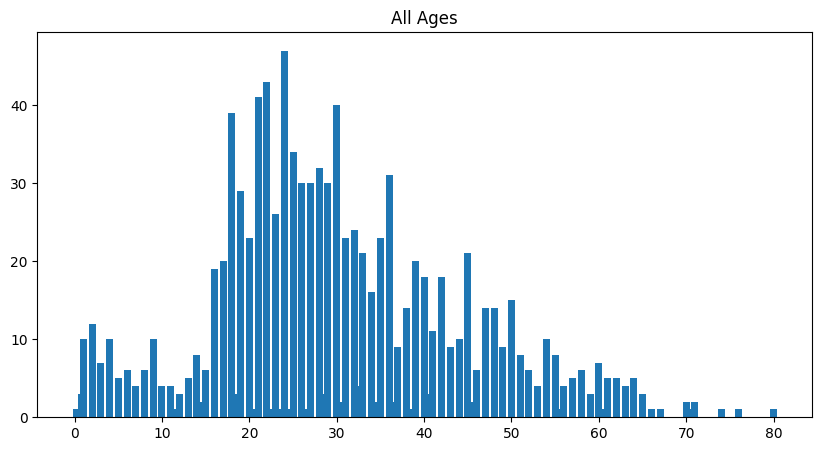

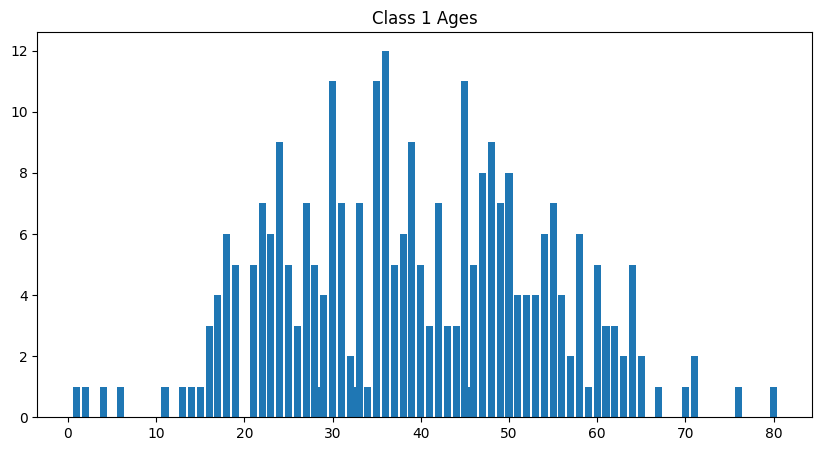

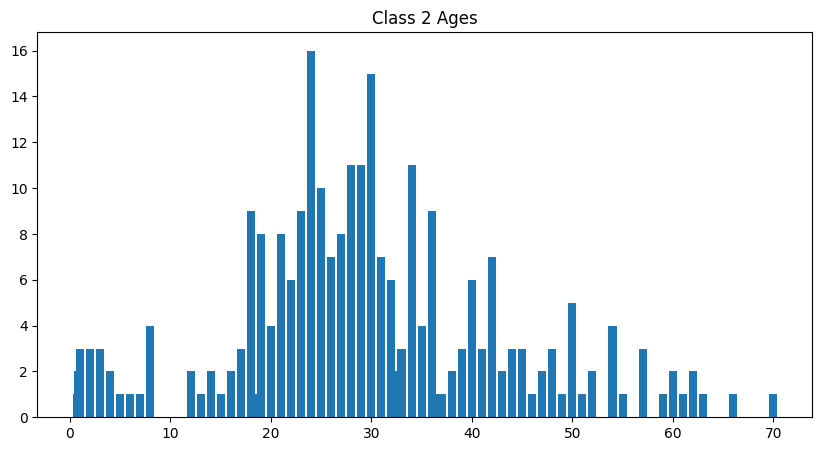

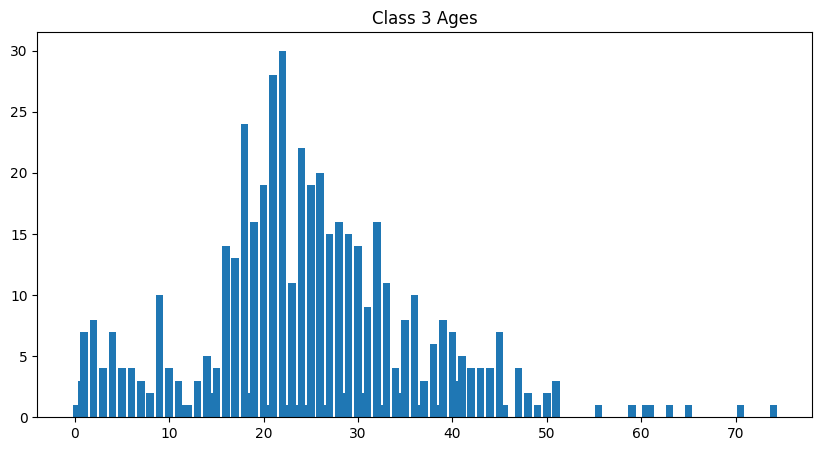

In [4]:
#Visualize age distribution
def plot_age_distribution(df):
    y = df['Age'].value_counts()
    plt.figure(figsize=(10,5))
    plt.bar(y.index.values, y)
    plt.title("All Ages")
    plt.show()

    for i in range(1, len(unique_classes)+ 1):
        y = df[df["Pclass"] == i]["Age"].value_counts()
        plt.figure(figsize=(10,5))
        plt.bar(y.index.values, y)
        plt.title(f"Class {i} Ages")
        plt.show()

plot_age_distribution(combined_pd)

In [5]:
# Fill missing ages
def fill_age_by_pclass(df):
    median_ages = df.groupby("Pclass")["Age"].median()
    for pclass, median in median_ages.items():
        idx = np.where((df["Pclass"] == pclass) & (df["Age"].isnull()))[0]
        df.loc[idx, "Age"] = median
    return df

combined_pd = fill_age_by_pclass(combined_pd)

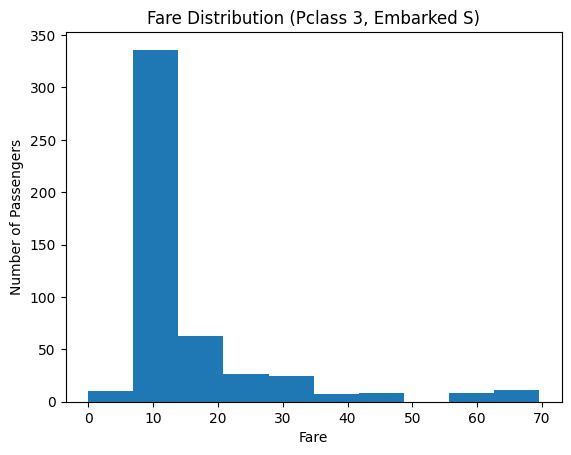

Passengers at class 3 and from embark S median fare is: 8.05


In [6]:
# Missing fare is Pclass 3, Embarked S - fill with group median
fares = combined_pd[(combined_pd["Pclass"] == 3) & (combined_pd["Embarked"] == "S")]["Fare"]

#Visualizes how fares are distributed in this group
def plot_fare_distribution_class3(fares):
    plt.hist(fares)
    plt.xlabel("Fare")
    plt.ylabel("Number of Passengers")
    plt.title("Fare Distribution (Pclass 3, Embarked S)")
    plt.show()

plot_fare_distribution_class3(fares)
fares_median = fares.median()

print(f"Passengers at class 3 and from embark S median fare is: {fares_median}")

combined_pd["Fare"] = combined_pd["Fare"].fillna(fares_median)

In [7]:
# flag missing embark rows (Pclass 1, Fare between 70 and 90)
missing_embark_flag = (combined_pd["Pclass"] == 1) & combined_pd["Fare"].between(70, 90)

#select that subset of Embarked
embarks = combined_pd.loc[missing_embark_flag, "Embarked"]

#common embark
common_embark = embarks.mode()[0]

#fill missing embark based on the mask condition
combined_pd["Embarked"] = combined_pd["Embarked"].fillna(common_embark)

In [8]:
#Fill all missing cabins with M
combined_pd["Cabin"] = combined_pd["Cabin"].fillna("M")

# Keep only the first letter
combined_pd["Cabin"] = combined_pd["Cabin"].str[0]

# 'T' cabin is unknown need to replace by M 
t_idx = np.where(combined_pd["Cabin"]== "T")[0]

combined_pd.loc[t_idx,"Cabin"] = "M"


In [9]:
#Creating a Title column to identify passangers status
combined_pd['Name'].unique()

names = combined_pd['Name']

last_name = []

titles = []
first_names = []

for name in names:
    if ', ' not in name:
        last_name.append('')
    else:
        last,name = name.split(', ',1)
        last_name.append(last)

    if '. ' not in name:
        titles.append('')
    else:
        title, first = name.split('. ',1)
        titles.append(title)
        first_names.append(first)

last_name = np.array(last_name)
titles = np.array(titles)
first_names = np.array(first_names)

idx = np.where(np.isin(titles, ['Capt', 'Col', 'Major']))
titles[idx] = 'Military'

idx = np.where(np.isin(titles, ['Don', 'Dona', 'Jonkheer', 'Lady', 'Sir', 'Master', 'the Countess']))
titles[idx] = 'Nobility'

idx = np.where(np.isin(titles, ['Miss', 'Mlle', 'Ms']))
titles[idx] = 'Ms'

idx = np.where(np.isin(titles, ['Mrs', 'Mme']))
titles[idx] = 'Mrs'

combined_pd['Title'] = titles

In [10]:
#binning the ages
age_bin = np.arange(0,81,10)

combined_pd['Age_bin'] = pd.cut(combined_pd['Age'],age_bin)

In [11]:

ticket_dict = dict(combined_pd['Ticket'].value_counts())

combined_pd['tik_count'] = combined_pd['Ticket'].map(ticket_dict)

In [12]:
#binning the fares
combined_pd['Fare_per_Ticket'] = combined_pd['Fare']/combined_pd['tik_count']

fare_bin = [0,20,40,60,80,150]
combined_pd['Fare_Bin'] = pd.cut(combined_pd['Fare_per_Ticket'],fare_bin)


In [13]:
#drop unneeded coloumns

combined_pd.drop(['Name','Age','Ticket','Fare','tik_count','Fare_per_Ticket'],axis=1,inplace=True)

In [14]:
combined_pd['Num_Family'] = combined_pd['SibSp'] + combined_pd['Parch'] +1
combined_pd['Is_Alone'] = (combined_pd['Num_Family'] == 1).astype(int)
combined_pd['Woman_3rd'] = ((combined_pd['Sex'] == 'female') & (combined_pd['Pclass'] == 3)).astype(int)

In [15]:
#set index
combined_pd.set_index('PassengerId',inplace=True)

# Drop columns that don't help
combined_pd.drop(['SibSp', 'Parch'], axis=1, inplace=True)

# Direct encoding - no LabelEncoder needed
one_hot = pd.get_dummies(combined_pd.astype(str), 
                         columns=['Sex', 'Embarked', 'Title', 
                                  'Cabin', 'Age_bin', 'Fare_Bin', 'Pclass'])

# Convert bool columns to int
one_hot = one_hot.astype(int)


In [16]:
X = one_hot.loc[train_idx].values
y = survived.values

In [17]:
X_train,X_test,y_train,y_test = train_test_split(X,y,random_state=0,test_size=.2)

In [18]:
best_model = RandomForestClassifier(
    max_depth=6,
    max_features='log2',
    min_samples_leaf=1,
    min_samples_split=2,
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
pipe = Pipeline([
    ('scaler', StandardScaler()),  
    ('classifier', best_model)
])

##How I got my model hypertune 
'''
param_grid = {
    'classifier__n_estimators': [50, 100, 200],        # number of trees
    'classifier__max_depth': [None, 5, 10, 20],        # max depth of each tree
    'classifier__min_samples_split': [2, 5, 10],       # min samples to split a node
    'classifier__min_samples_leaf': [1, 2, 4],         # min samples per leaf
    'classifier__max_features': ['sqrt', 'log2', None] # features considered at each split
}
grid_search = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    cv=5,               
    scoring='accuracy', 
    n_jobs=-1            
)
grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation Accuracy:", grid_search.best_score_)

best_model = grid_search.best_estimator_
test_accuracy = best_model.score(X_test, y_test)
print("Test Accuracy:", test_accuracy) is the the best hyper
'''

pipe.fit(X_train, y_train)  # train on 80% first
score = pipe.score(X_test, y_test)  # validate on 20%
print("Validation Accuracy:", score)
pipe.fit(X, y)

Validation Accuracy: 0.8212290502793296


,steps,"[('scaler', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,n_estimators,100
,criterion,'gini'
,max_depth,6
,min_samples_split,2


In [19]:
X_kaggle = one_hot.loc[test_idx].values

predictions = pipe.predict(X_kaggle)

submission = pd.DataFrame({
    'PassengerId': test_idx.values,
    'Survived': predictions
})

submission.to_csv('../data/submission.csv', index=False)